In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
#reading train data
train=pd.read_csv("/kaggle/input/spaceship-titanic/train.csv")

#reading test data
test=pd.read_csv("/kaggle/input/spaceship-titanic/test.csv")

### EDA

In [3]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
train.shape

(8693, 14)

In [5]:
train.columns

Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [7]:
#analysing Transported column
train['Transported'].value_counts()

True     4378
False    4315
Name: Transported, dtype: int64

<AxesSubplot:xlabel='Transported', ylabel='count'>

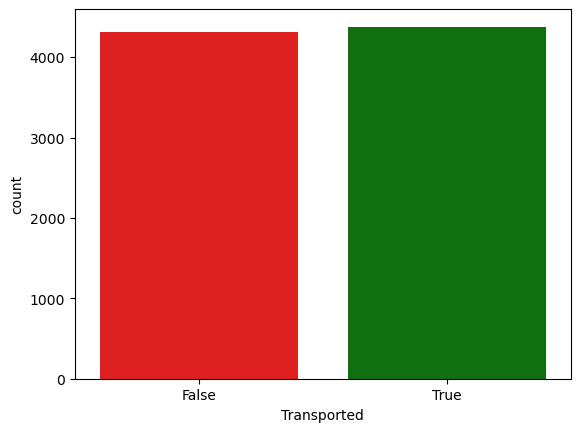

In [8]:
#countplot
sns.countplot(x='Transported',data=train,palette=['r','g'])

<AxesSubplot:xlabel='VIP', ylabel='count'>

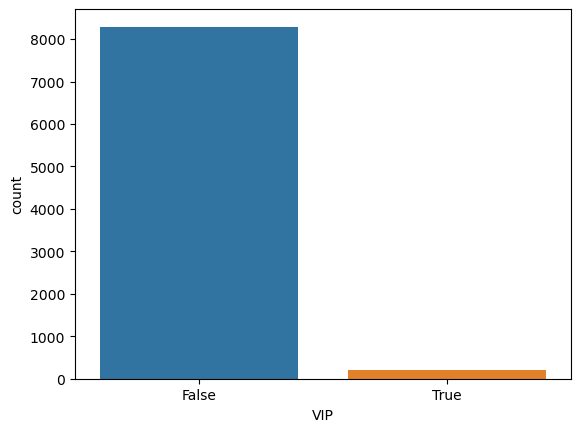

In [9]:
#analysing VIP column
sns.countplot(x='VIP',data=train)

In [10]:
#create new feature
train['Not Transported']=1-train['Transported']

<AxesSubplot:xlabel='VIP'>

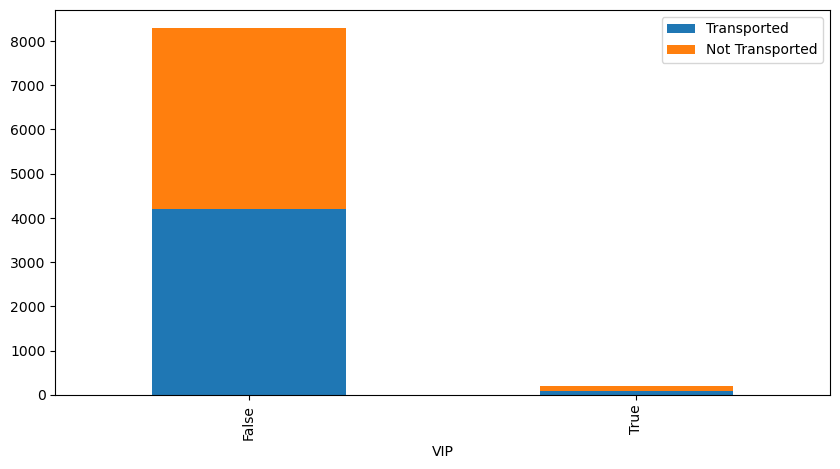

In [11]:
#visulazing transported based VIP column
train.groupby('VIP').agg('sum')[['Transported','Not Transported']].plot(kind='bar',figsize=(10,5),stacked=True)

### Data Cleaning

In [12]:
#checking the no of null values in the dataset
train.isnull().sum().sort_values(ascending=False)

CryoSleep          217
ShoppingMall       208
VIP                203
HomePlanet         201
Name               200
Cabin              199
VRDeck             188
FoodCourt          183
Spa                183
Destination        182
RoomService        181
Age                179
PassengerId          0
Transported          0
Not Transported      0
dtype: int64

In [13]:
#droping unwanted columns
df1=train.drop(['Name','Cabin','Not Transported'],axis=1)

In [14]:
#filling null values with mean in numerical columns

df1['Age']=df1['Age'].fillna(df1['Age'].mean())
df1['RoomService']=df1['RoomService'].fillna(df1['RoomService'].mean())
df1['FoodCourt']=df1['FoodCourt'].fillna(df1['FoodCourt'].mean())
df1['ShoppingMall']=df1['ShoppingMall'].fillna(df1['ShoppingMall'].mean())
df1['Spa']=df1['Spa'].fillna(df1['Spa'].mean())
df1['VRDeck']=df1['VRDeck'].fillna(df1['VRDeck'].mean())

In [15]:
#filling null values with mode in categorical columns

df1['HomePlanet']=df1['HomePlanet'].fillna(df1['HomePlanet'].mode()[0])
df1['CryoSleep']=df1['CryoSleep'].fillna(df1['CryoSleep'].mode()[0])
df1['Destination']=df1['Destination'].fillna(df1['Destination'].mode()[0])
df1['VIP']=df1['VIP'].fillna(df1['VIP'].mode()[0])

In [16]:
#checking null values
df1.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
dtype: int64

In [17]:
df1.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,0001_01,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False
1,0002_01,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True
2,0003_01,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False
3,0003_02,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False
4,0004_01,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True


In [18]:
df1.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000,8693.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.339054,659.739364,1594.434978,597.417440,1124.675871,1133.259049
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,37.000000,78.000000,118.000000,45.000000,89.000000,71.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


<AxesSubplot:>

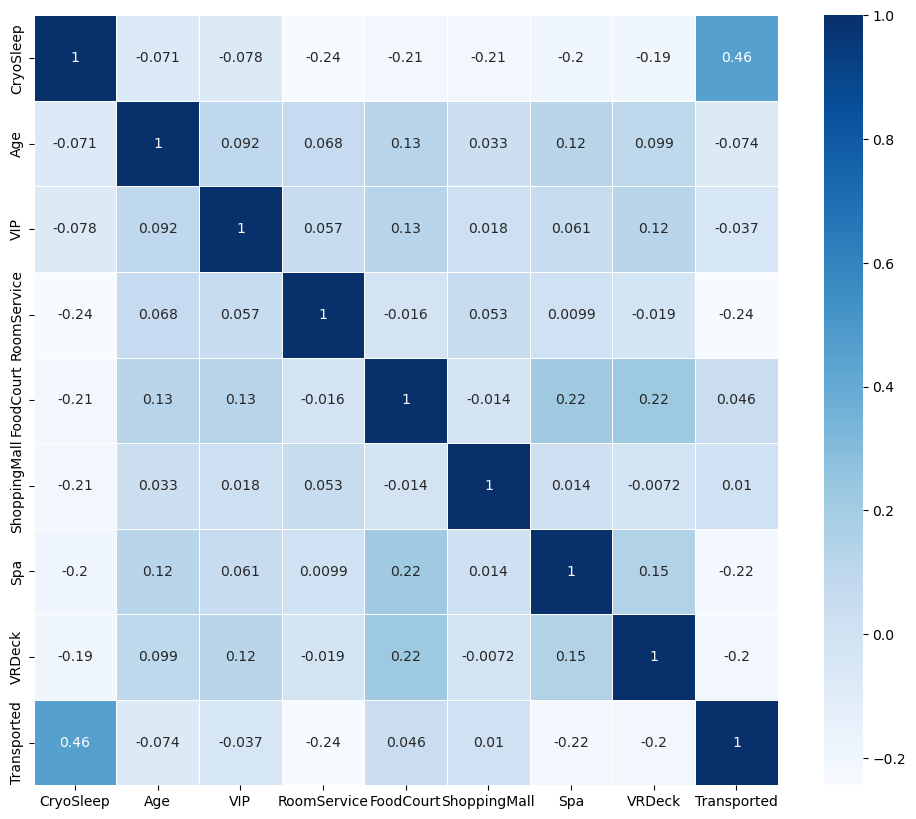

In [19]:
#correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(df1.corr(),annot=True,linewidth=0.4,cmap='Blues')

In [20]:
#converting categorical feature into numerical feature
df1.HomePlanet=df1.HomePlanet.map({'Europa':0,'Earth':1,'Mars':2})

In [21]:
df1.Destination=df1.Destination.map({'TRAPPIST-1e':0,'PSO J318.5-22':1,'55 Cancri e':2})

In [22]:
df1["CryoSleep"].replace(False,0,inplace=True)
df1["CryoSleep"].replace(True,1,inplace=True)
df1["VIP"].replace(False,0,inplace=True)
df1["VIP"].replace(True,1,inplace=True)
df1["Transported"].replace(False,0,inplace=True)
df1["Transported"].replace(True,1,inplace=True)

In [23]:
df1.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,0001_01,0,0,0,39.0,0,0.0,0.0,0.0,0.0,0.0,0
1,0002_01,1,0,0,24.0,0,109.0,9.0,25.0,549.0,44.0,1
2,0003_01,0,0,0,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0
3,0003_02,0,0,0,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0
4,0004_01,1,0,0,16.0,0,303.0,70.0,151.0,565.0,2.0,1


### Data Modeling

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(df1.drop(['Transported'],axis=1),df1.Transported,test_size=0.2,random_state=0,stratify=df1.Transported)


In [25]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

In [26]:
from sklearn.metrics import accuracy_score

Y_pred=lr.predict(X_test)
accuracy_score(y_test,Y_pred)

0.7665324899367453

### Confusion Matrix

In [27]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,Y_pred)
cm

array([[578, 285],
       [121, 755]])

<AxesSubplot:>

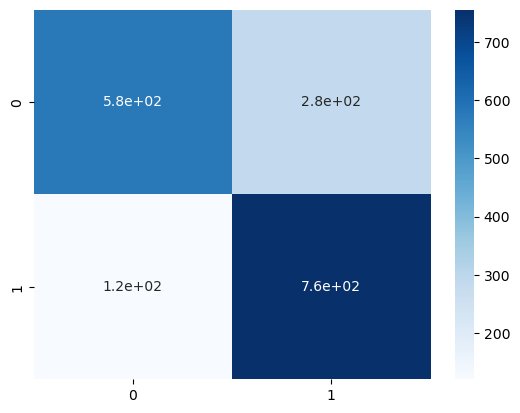

In [28]:
sns.heatmap(cm,annot=True,cmap='Blues')

### Cleaning test dataset

In [29]:
#test dataset
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez


In [30]:
test.shape

(4277, 13)

In [31]:
#checking null values
test.isnull().sum()

PassengerId       0
HomePlanet       87
CryoSleep        93
Cabin           100
Destination      92
Age              91
VIP              93
RoomService      82
FoodCourt       106
ShoppingMall     98
Spa             101
VRDeck           80
Name             94
dtype: int64

In [32]:
#droping unwanted columns
df2=test.drop(['Cabin', 'Name'],axis=1)

In [33]:
#filling null values with mean in numerical columns

df2['Age']=df2['Age'].fillna(df2['Age'].mean())
df2['RoomService']=df2['RoomService'].fillna(df2['RoomService'].mean())
df2['FoodCourt']=df2['FoodCourt'].fillna(df2['FoodCourt'].mean())
df2['ShoppingMall']=df2['ShoppingMall'].fillna(df2['ShoppingMall'].mean())
df2['Spa']=df2['Spa'].fillna(df2['Spa'].mean())
df2['VRDeck']=df2['VRDeck'].fillna(df2['VRDeck'].mean())

In [34]:
#filling null values with mode in categorical columns

df2['HomePlanet']=df2['HomePlanet'].fillna(df2['HomePlanet'].mode()[0])
df2['CryoSleep']=df2['CryoSleep'].fillna(df2['CryoSleep'].mode()[0])
df2['Destination']=df2['Destination'].fillna(df2['Destination'].mode()[0])
df2['VIP']=df2['VIP'].fillna(df2['VIP'].mode()[0])

In [35]:
df2.isnull().sum()

PassengerId     0
HomePlanet      0
CryoSleep       0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
dtype: int64

In [36]:
#converting categorical feature into numerical feature
df2.HomePlanet=df2.HomePlanet.map({'Europa':0,'Earth':1,'Mars':2})
df2.Destination=df2.Destination.map({'TRAPPIST-1e':0,'PSO J318.5-22':1,'55 Cancri e':2})

In [37]:
df2['HomePlanet'].unique()

array([1, 0, 2])

In [38]:
df2["CryoSleep"].replace(False,0,inplace=True)
df2["CryoSleep"].replace(True,1,inplace=True)
df2["VIP"].replace(False,0,inplace=True)
df2["VIP"].replace(True,1,inplace=True)


In [39]:
df2.head()

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,0013_01,1,1,0,27.0,0,0.0,0.0,0.0,0.0,0.0
1,0018_01,1,0,0,19.0,0,0.0,9.0,0.0,2823.0,0.0
2,0019_01,0,1,2,31.0,0,0.0,0.0,0.0,0.0,0.0
3,0021_01,0,0,0,38.0,0,0.0,6652.0,0.0,181.0,585.0
4,0023_01,1,0,0,20.0,0,10.0,0.0,635.0,0.0,0.0


In [40]:
#train datset shape
df1.shape

(8693, 12)

In [41]:
#test datset shape
df2.shape

(4277, 11)

In [42]:
pred=lr.predict(df2)
pred

array([1, 0, 1, ..., 1, 1, 1])

In [43]:
a=df2['PassengerId']
a.shape

(4277,)

In [44]:
x=pd.DataFrame(a)
x

,PassengerId
0,0013_01
1,0018_01
2,0019_01
3,0021_01
4,0023_01
...,...
4272,9266_02
4273,9269_01
4274,9271_01
4275,9273_01


In [45]:
b=pred
y=pd.DataFrame(b)

In [46]:
y.replace(0,False,inplace=True)
y.replace(1,True,inplace=True)

In [47]:
final=pd.concat([x,y],axis=1)

In [48]:
final.rename(columns={0:'Transported'},inplace=True)
final

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
...,...,...
4272,9266_02,True
4273,9269_01,True
4274,9271_01,True
4275,9273_01,True


In [49]:
final.to_csv('spaceship_titanic.csv',index=False)

<AxesSubplot:xlabel='Transported', ylabel='count'>

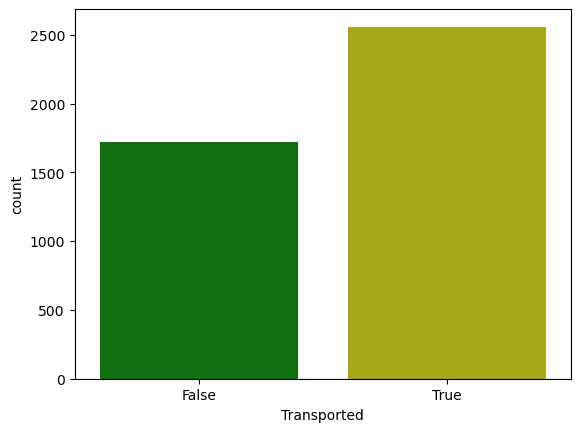

In [50]:
#visualizing predicted values
sns.countplot(x='Transported',data=final,palette=['g','y'])